# Расчётно-графическая работа №1
**Описание выборки. Оценивание параметров.
Доверительные интервалы**

In [1]:
COLUMN = 1

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math

from sires.SortedSires import SortedSires
from sires.SiresInfo import SiresInfo

from hist.Histogram import Histogram
from hist.IntervalRules import IntervalRules

from distrib.DistribType import DistribType
from distrib.Estimation import Estimation
from distrib.DistribDencity import DistribDencity
from distrib.EstimatedParamsPlots import EstimatedParamsPlots
from distrib.ParametricProb import ParametricProb
from distrib.ConfidenceIntervals import ConfidenceIntervals

from utils.Reader import Reader

from func.EmpericalDistribFunc import EmpericalDistribFunc

Читаем данные из файла и подготавливаем всякое


In [3]:
file = Reader("../RGR1_A-8_X1-X4.csv")
sorted_data = SortedSires(file.read_column(COLUMN-1))
sires_info = SiresInfo(sorted_data)

## 1 Первичное описание выборки

### 1.1 Вариационный ряд

In [4]:
sorted_data

Вариационный ряд
   Всего эдементов: 200
   Первые 5 элементов: 17.82, 18.26, 18.37, 18.46, 18.83
   Последние 5 элементов: 75.32, 75.08, 75.03, 74.65, 74.13

### 1.2 Эмпирическая функция распределения

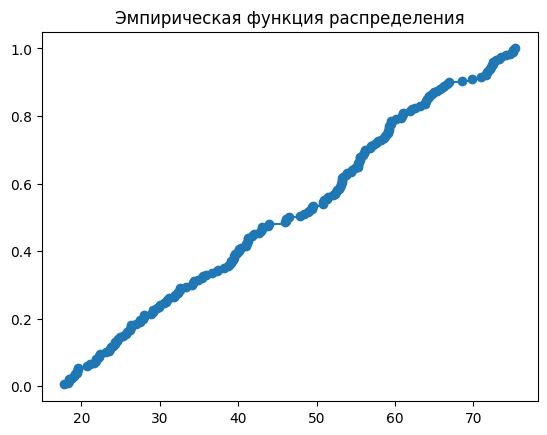

In [5]:
EmpericalDistribFunc(sorted_data).draw()
plt.show()

### 1.3 Построение гистограм

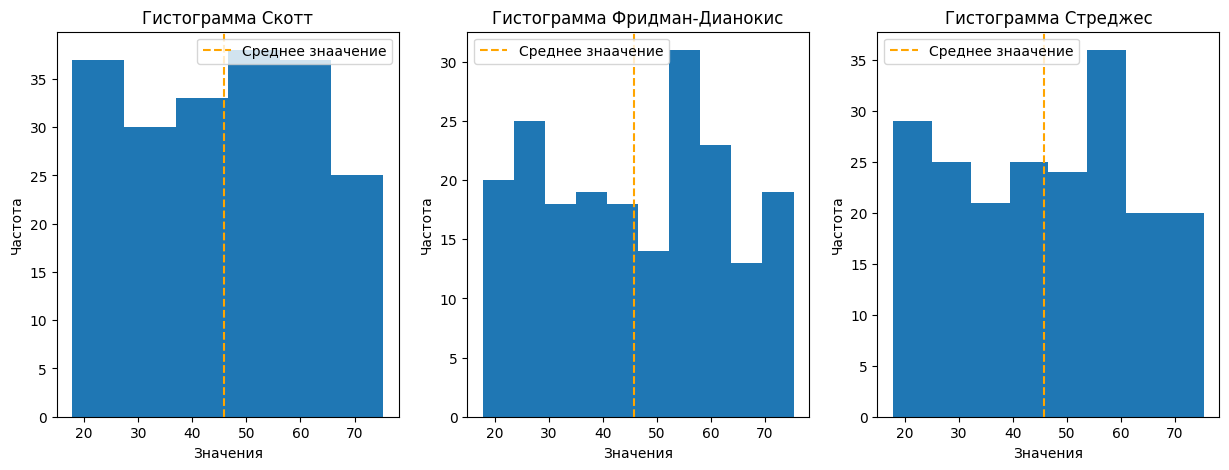

In [6]:
Histogram(sorted_data).draw_all()

### 1.4 Основные характеристики выборки

In [7]:
sires_info

Выборочные оценки:
    Среднее:                    x̄ = 45.836
    Медиана:                    x̃ =  47.180
    Размах:                     [17.8, 75.3]
    Дисперсия (смещённая):      S² =  272.204
    Дисперсия (несмещённая):    σ² =  273.572
    Ст. отклонение (смещ.):     S =  16.499
    Ст. отклонение (несмещ.):   σ =  16.540
    Квантиль 25%:               30.858
    Квантиль 50%:               47.180
    Квантиль 75%:               59.058

### Форма распределения

График симметричен\
Есть небольшие выбросы (особенно заметно на гистограмме по Фридману-Диаконису)\
Отсутствуют естественные границы значений

## 2 Предположение о виде закона распределения


Наблюдаемое распредение - **равномерное**

Визуально по гистограммам видно, что значения распределены равномерно, что характкрно для равномерного распределения.\
Симметричность графика характерна для равномерного распределения, где все значения имеют одинаковую вероятность в пределах диапазона.\

In [10]:
dist_type = DistribType.UNIFORM

In [11]:
def show_estimation_results(dist_params, dist: DistribType) -> None:
    if dist == DistribType.NORMAL:
        print("\n=== Нормальное распределение ===")
        print(f"Метод моментов: â = {dist_params[0].a:.3f},   σ̂ = {math.sqrt(dist_params[0].sigma2):.3f}")
        print(f"ММП:            â = {dist_params[1].a:.3f},   σ̂ = {math.sqrt(dist_params[1].sigma2):.3f}")

    if dist == DistribType.UNIFORM:
        print("\n=== Равномерное распределение ===")
        print(f"Метод моментов: â = {dist_params[0].a:.3f},   b̂ = {dist_params[0].b:.3f}")
        print(f"ММП:            â = {dist_params[1].a:.3f},   b̂ = {dist_params[1].b:.3f}")

    if dist == DistribType.EXP:
        print("\n=== Экспоненциальное распределение ===")
        print(f"Метод моментов: λ̂ = {dist_params[0].l:.3f},   ĉ = {dist_params[0].c:.3f}")
        print(f"ММП:            λ̂ = {dist_params[1].l:.3f},   ĉ = {dist_params[1].c:.3f}")

dist_params = Estimation(sires_info, dist_type)()
show_estimation_results(dist_params, dist_type)


=== Равномерное распределение ===
Метод моментов: â = 17.259,   b̂ = 74.412
ММП:            â = 17.820,   b̂ = 75.320


*Графики плотностей*

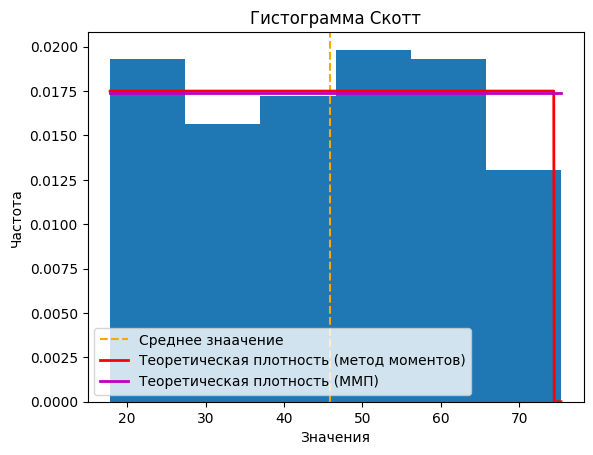

In [12]:
Histogram(sorted_data, True).draw(IntervalRules.SCOTT)

x_range = np.linspace(sorted_data.get_min(), sorted_data.get_max(), 1000)

dencity = DistribDencity(dist_params[0], dist_type).get_dencity()
y_range = [dencity(x) for x in x_range]
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Теоретическая плотность (метод моментов)')

dencity = DistribDencity(dist_params[1], dist_type).get_dencity()
y_range = [dencity(x) for x in x_range]
plt.plot(x_range, y_range, 'm-', linewidth=2, label='Теоретическая плотность (ММП)')

plt.legend()
plt.show()

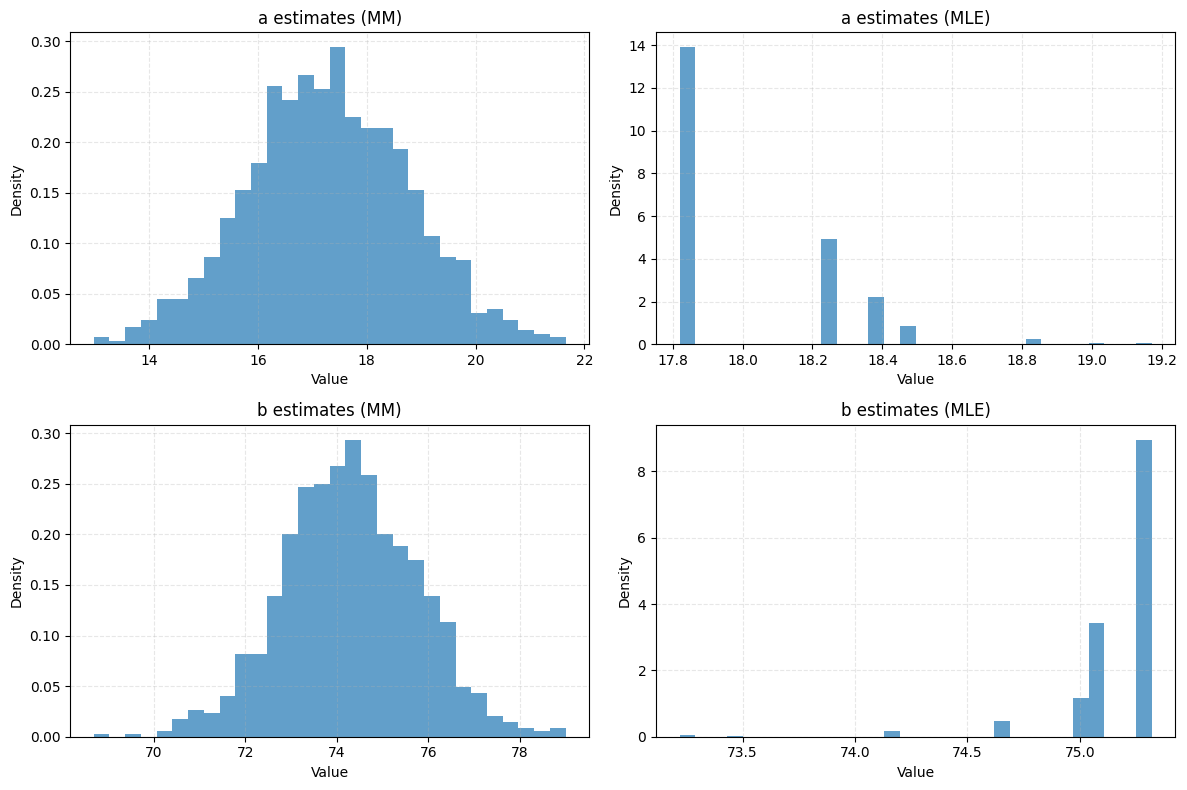

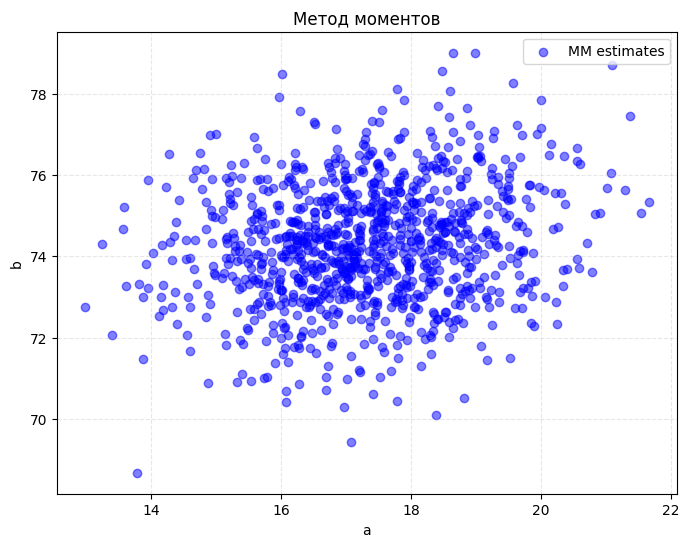

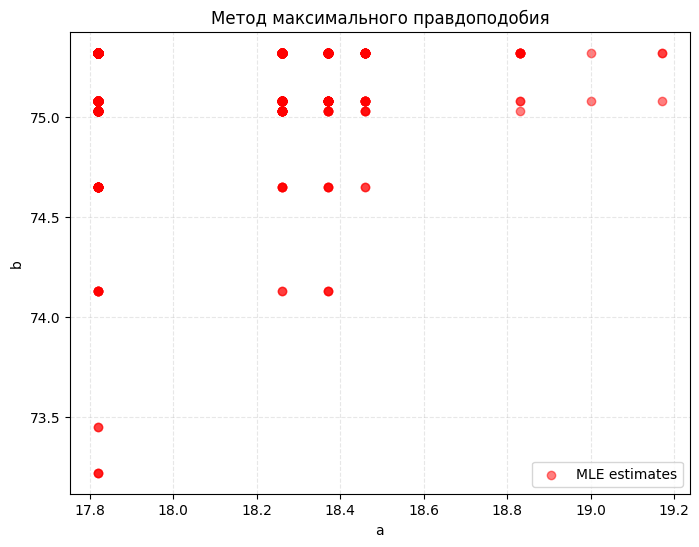

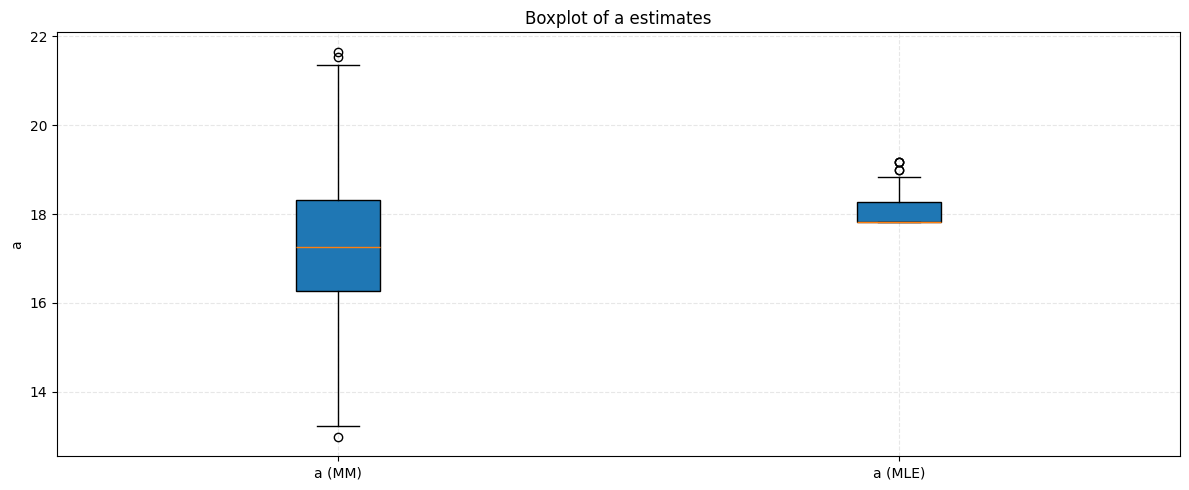

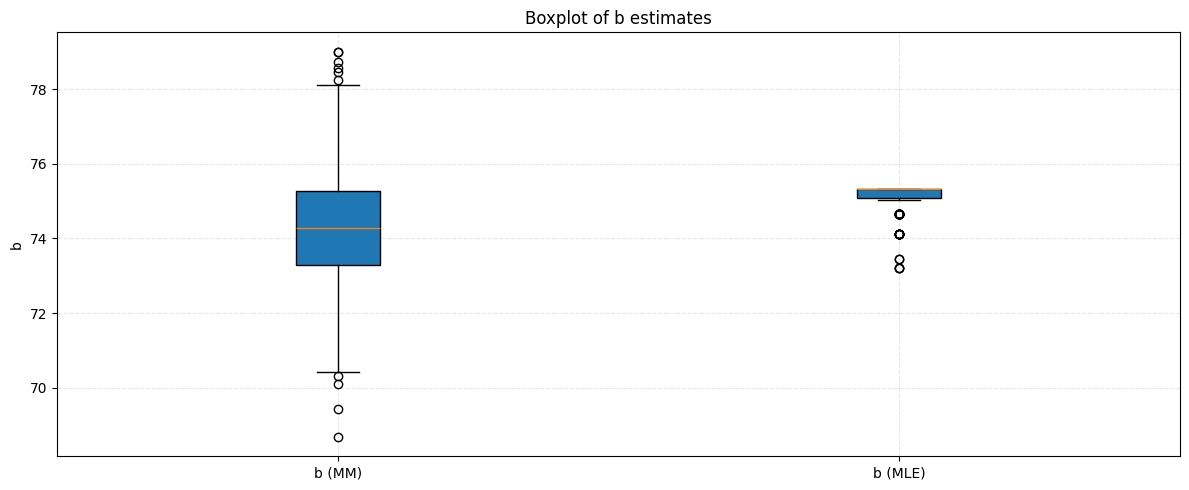

In [13]:
EstimatedParamsPlots(sorted_data, dist_type).draw()

## 4 Оценивание параметрической вероятности двумя способами

In [14]:
result = ParametricProb(sorted_data, dist_type)()
print(f"Эмпирическая оценка P(X > x0):     {result[0]:.3f}")
print(f"Параметрическая оценка P(X > x0):  {result[1]:.3f}")

Эмпирическая оценка P(X > x0):     0.180
Параметрическая оценка P(X > x0):  0.225


## 5. Оценка моментов по сгруппированной выборке

In [15]:
def grouped_moments(data: list[float], bins: int):
    n = len(data)
    counts, bin_edges = np.histogram(data, bins=bins)
    midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
    mean_grouped = np.sum(counts * midpoints) / n
    var_grouped = np.sum(counts * (midpoints - mean_grouped)**2) / (n - 1)

    return mean_grouped, var_grouped

mean_grouped, s2_grouped = grouped_moments([i for i in sorted_data], bins=7)


print("=== По исходным данным ===")
print(f"Среднее:                        {sires_info.mean:.3f}")
print(f"Дисперсия (несмещённая):        {sires_info.s2:.3f}")

print("\n=== По сгруппированной выборке ===")
print(f"Среднее:                        {mean_grouped:.3f}")
print(f"Дисперсия (несмещённая):        {s2_grouped:.3f}")

print("\n=== Абсолютные Погрешности ===")
print(f"Среднее:                        {abs(sires_info.mean - mean_grouped):.3f}")
print(f"Дисперсия (несмещённая):        {abs(sires_info.s2 - s2_grouped):.3f}")

print("\n=== Относительные Погрешности ===")
print(f"Среднее:                        {abs(sires_info.mean - mean_grouped)/sires_info.mean:.3f}")
print(f"Дисперсия (несмещённая):        {abs(sires_info.s2 - s2_grouped)/sires_info.s2:.3f}")

=== По исходным данным ===
Среднее:                        45.836
Дисперсия (несмещённая):        273.572

=== По сгруппированной выборке ===
Среднее:                        45.790
Дисперсия (несмещённая):        263.522

=== Абсолютные Погрешности ===
Среднее:                        0.046
Дисперсия (несмещённая):        10.050

=== Относительные Погрешности ===
Среднее:                        0.001
Дисперсия (несмещённая):        0.037


## 6. Доверительные интервалы

In [16]:
_ = ConfidenceIntervals(sires_info).CPT()

print("\n=== EX по ЦПТ ===")
print(f"[{_[0]:.3f}; {_[1]:.3f}]")

if dist_type == DistribType.NORMAL:
    _ = ConfidenceIntervals(sires_info).uniform_exact()

    print("\n=== Точный μ для нормального распределения ===")
    print(f"[{_[0][0]:.3f}; {_[0][1]:.3f}]")
    print("\n=== Точный σ² для нормального распределения ===")
    print(f"[{_[1][0]:.3f}; {_[1][1]:.3f}]")


=== EX по ЦПТ ===
[43.543; 48.128]
